In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = {}
for model in ['EGFR_MAPK', 'EGFR_MAPK_tegfr']:
    df[model] = pd.read_csv(f'eval_newcv_newselect/{model}/dream_cytof/evaluate_all_v39.csv')
    df[model]['model'] = model
df = pd.concat(
    list(df.values())
)

In [16]:
df.head()

,Unnamed: 0,dataset,ref,context,features,samples,pretrain,standardise_features,median_init,freeze_medians,...,warmup_fct,opt_steps,opt_mult,momentum,weight_decay,use_simple_linear_schedule,use_early_stopping,job,rmse,model
0,0,train,DMM,cytof_init,RFE_10_permute,0of5,True,False,avg_model,False,...,0.0,0.0,0.0,0.0,0.0,True,False,0.0,0.414421,EGFR_MAPK
1,1510,val,DMM,proteomics,HVGRFE_10_permute,2of5,True,False,avg_model,False,...,0.0,0.0,0.0,0.0,0.0,True,False,0.0,0.342675,EGFR_MAPK
2,1509,val,DMM,proteomics,HVGRFE_10_permute,1of5,True,False,avg_model,False,...,0.0,0.0,0.0,0.0,0.0,True,False,4.0,0.507969,EGFR_MAPK
3,1508,val,DMM,proteomics,HVGRFE_10_permute,1of5,True,False,avg_model,False,...,0.0,0.0,0.0,0.0,0.0,True,False,3.0,0.642778,EGFR_MAPK
4,1507,val,DMM,proteomics,HVGRFE_10_permute,1of5,True,False,avg_model,False,...,0.0,0.0,0.0,0.0,0.0,True,False,2.0,0.709530,EGFR_MAPK


In [17]:
df = df[df['features'].apply(lambda x: isinstance(x, str))]
df['n_features'] = df['features'].apply(lambda x: int(x.split('_')[1]))

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/

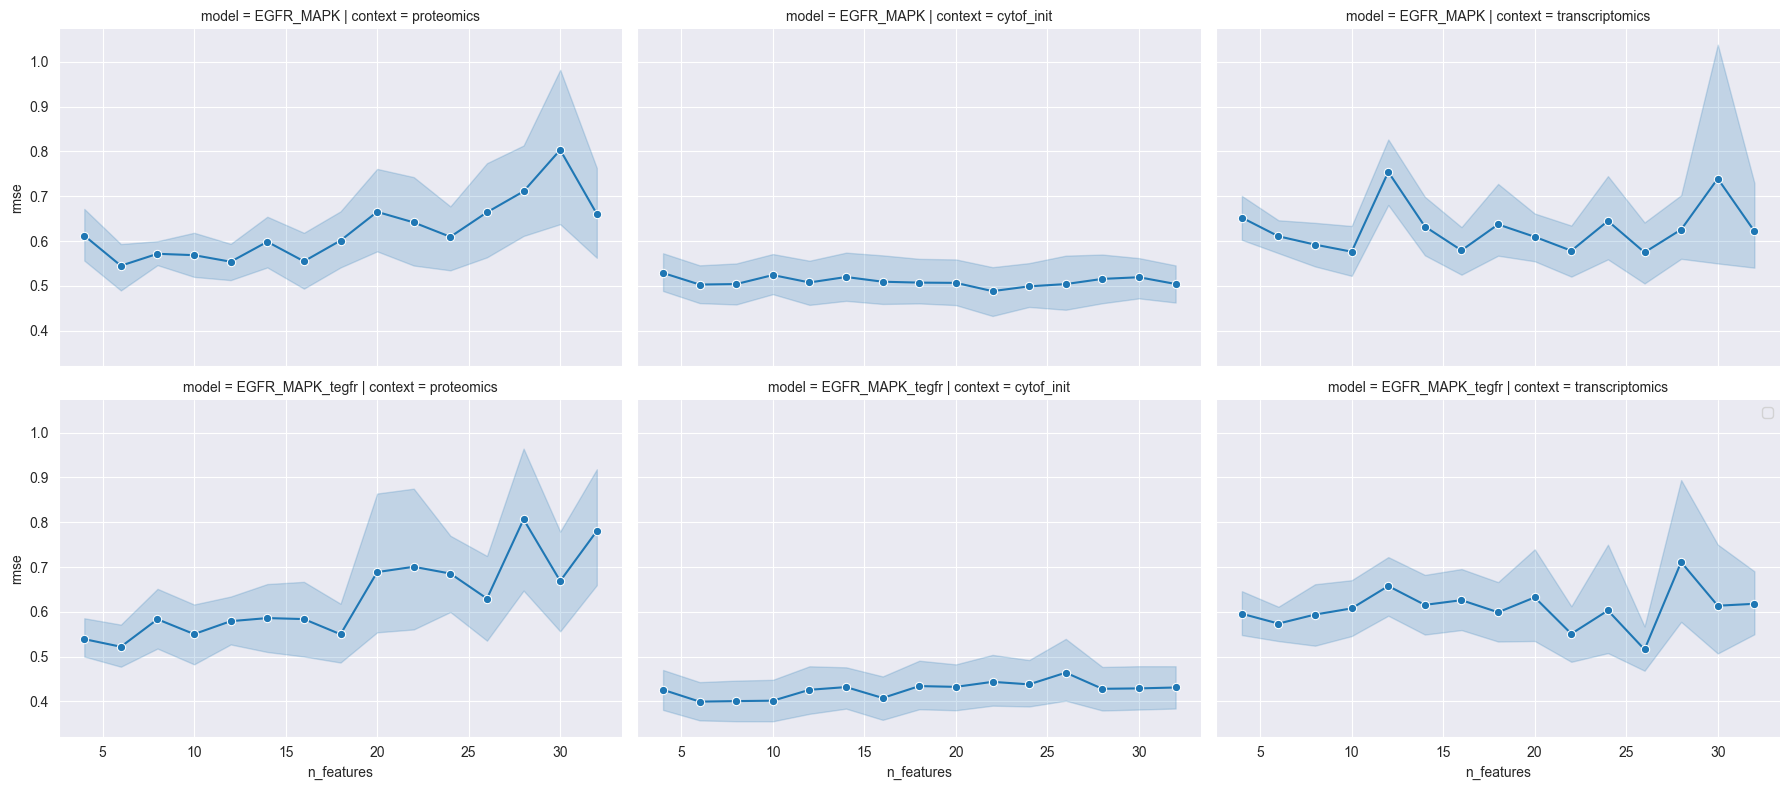

In [19]:
g = sns.FacetGrid(
    df[df['dataset'] == 'val'],
    col="context",
    row="model",
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="n_features",
    y="rmse",
    marker="o",
    dashes=False
)
plt.legend()

In [30]:
dfp = pd.pivot_table(
    df,
    index=['model', 'context', 'features', 'samples', 'job'],
    columns='dataset',
    values='rmse'
).reset_index()

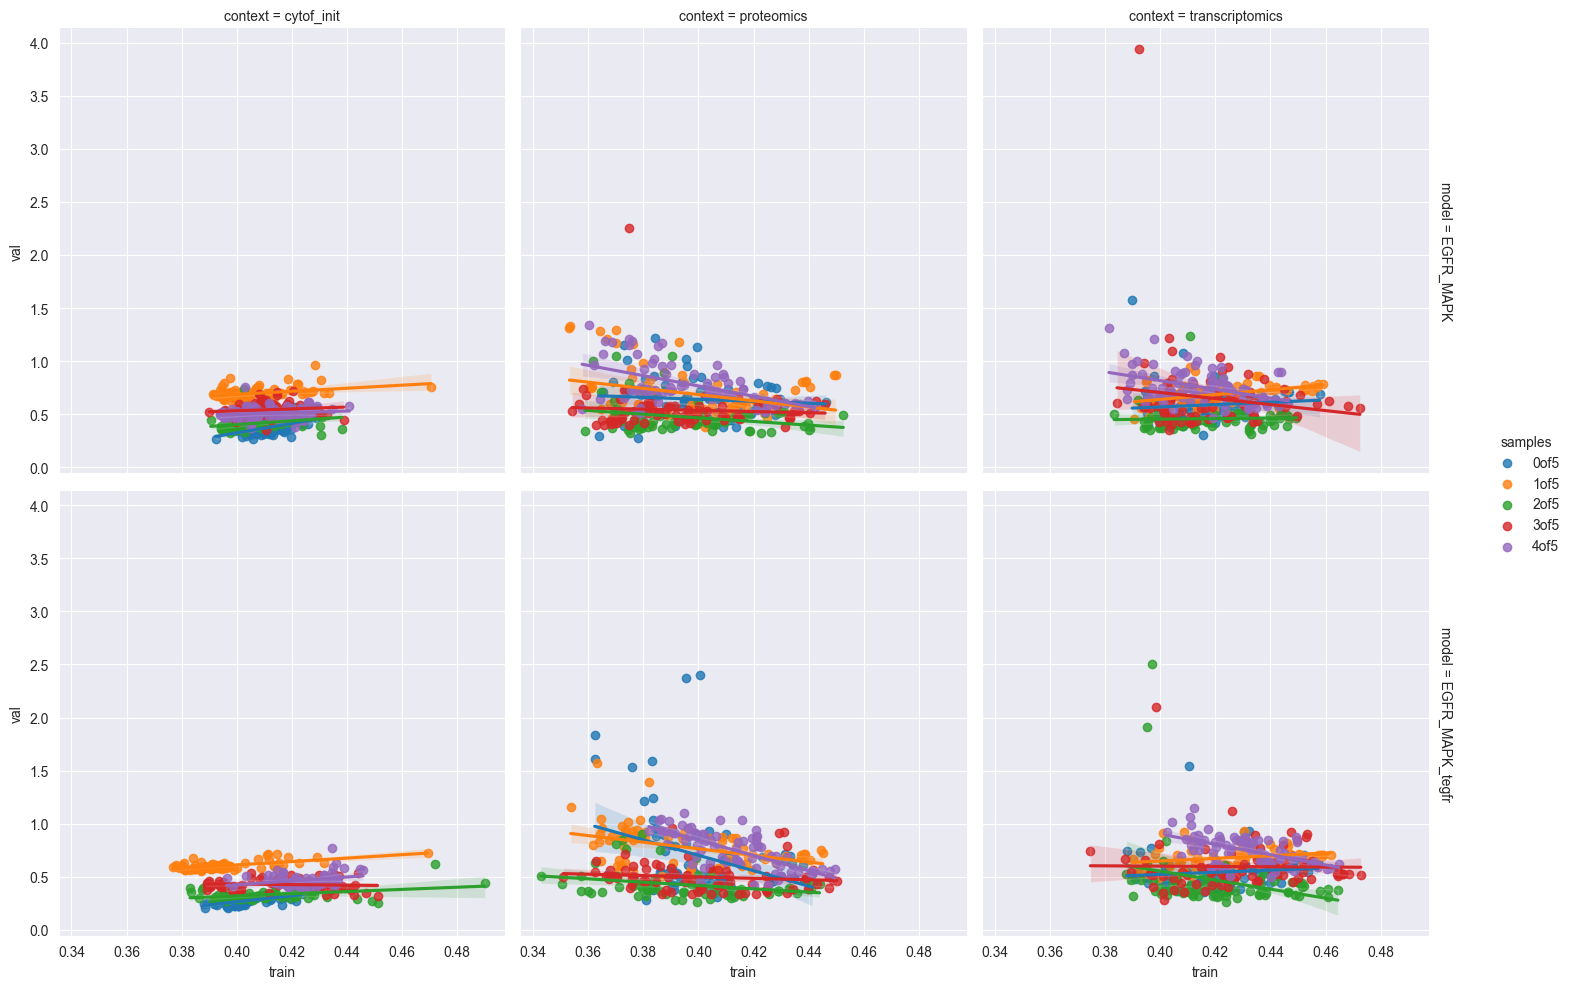

In [32]:
sns.lmplot(
    data=dfp[dfp['train'] < 0.5],
    x='train',
    y='val',
    hue='samples',
    col='context',
    row='model',
    height=5,
    aspect=1,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)